# Vital Signs EDA: Completeness, Missingness & Temporal Patterns

**Key questions:**
1. How are vitals stored? (one row per vital vs pivoted)
2. How many vitals are recorded at each timestamp? (complete vs sparse)
3. Is missingness random or systematic? Should we drop temperature?
4. What is the time delta between consecutive complete timestamps?
5. What timestep should we use for LSTM sequences?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import jaccard_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Ensure src is importable
sys.path.insert(0, str(Path.cwd().parent))

from src.eda.queries import run_query
from src.eda.vitals import (
    VITALS_6, VITALS_5, DISPLAY_NAMES, MISS_COLS,
    connect_vitals, compute_co_occurrence, decode_missingness_pattern,
    plot_completeness_bar, plot_heatmap, plot_delta_histogram, plot_temporal_panels,
    test_mcar_chi_square, test_conditional_distributions,
)

conn = connect_vitals()
print("Connected.")

Connected.


## 2. Data Structure Overview

In [2]:
schema = run_query(conn, "schema")
counts = run_query(conn, "counts")
sample = run_query(conn, "sample")

display(schema)
display(counts)
display(sample)

,column_name,column_type,null,key,default,extra
0,patient_id,VARCHAR,YES,None,None,None
1,encounter_id,VARCHAR,YES,None,None,None
2,effective_datetime,VARCHAR,YES,None,None,None
3,loinc_code,VARCHAR,YES,None,None,None
4,value,DOUBLE,YES,None,None,None
5,unit,VARCHAR,YES,None,None,None


,total_rows,unique_patients,unique_encounters,unique_vitals
0,10996821,205504,425087,6


,patient_id,encounter_id,effective_datetime,loinc_code,value,unit
0,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,2708-6,98.0,%
1,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8310-5,98.7,F
2,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8462-4,71.0,mm[Hg]
3,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8480-6,141.0,mm[Hg]
4,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8867-4,96.0,beats/minute
5,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,9279-1,18.0,breaths/minute
6,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,2708-6,98.0,%
7,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8310-5,98.7,F
8,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8462-4,71.0,mm[Hg]
9,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8480-6,141.0,mm[Hg]


## 3. Timestamp Completeness

How many of the 6 vitals are present at each timestamp?

,num_vitals,num_timestamps,pct
0,2,56365,2.95
1,3,34808,1.82
2,4,36987,1.94
3,5,522789,27.35
4,6,1260313,65.94


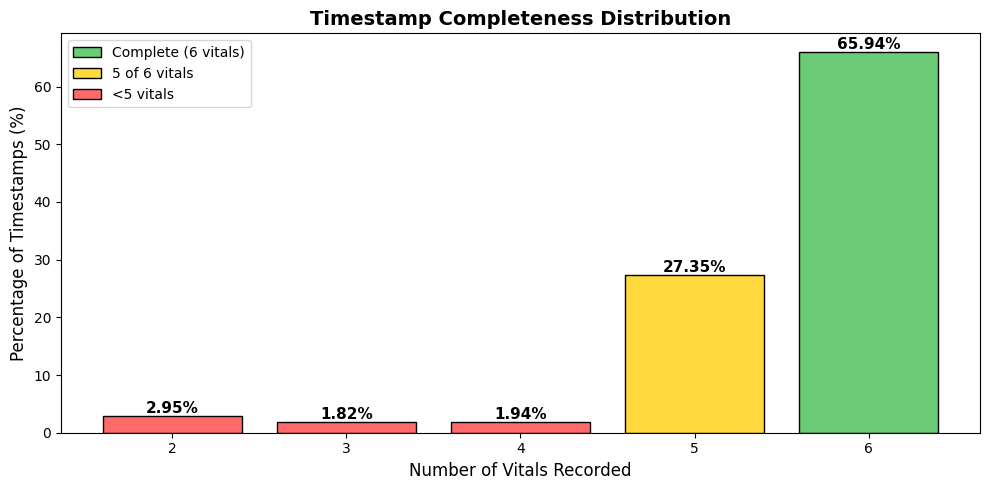

In [3]:
completeness = run_query(conn, "completeness")
display(completeness)

fig, ax = plt.subplots(figsize=(10, 5))
plot_completeness_bar(completeness, ax)
plt.tight_layout()
plt.show()

## 4. Missing Vital Analysis

When a timestamp has only 5 vitals, which one is missing?

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_loinc,times_missing,pct,vital_name
0,8310-5,471200,90.13,body_temperature
1,2708-6,42982,8.22,oxygen_saturation
2,9279-1,6895,1.32,respiratory_rate
3,8867-4,1712,0.33,heart_rate


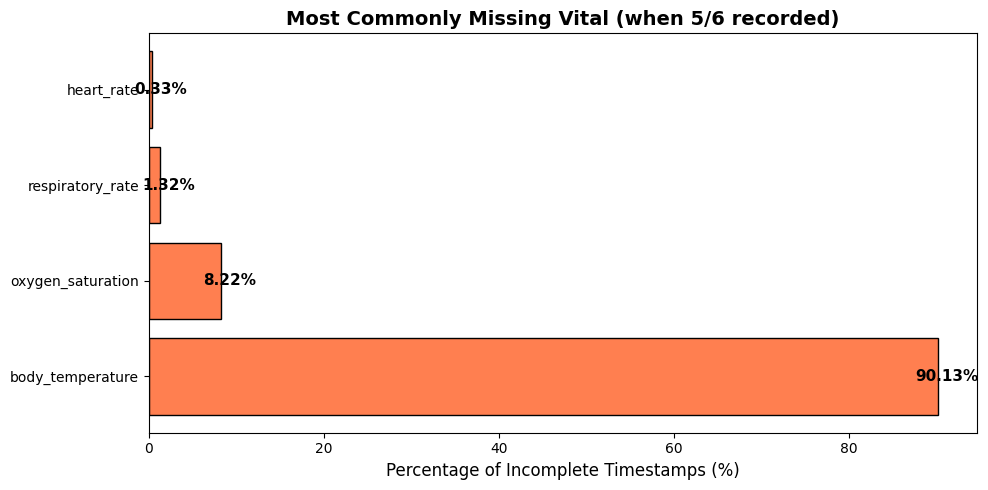

In [4]:
missing = run_query(conn, "missing_vital")
missing["vital_name"] = missing["missing_loinc"].map(VITALS_6)
display(missing)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing["vital_name"], missing["pct"], color="coral", edgecolor="black")
ax.set_xlabel("Percentage of Incomplete Timestamps (%)", fontsize=12)
ax.set_title("Most Commonly Missing Vital (when 5/6 recorded)", fontsize=14, fontweight="bold")
for bar, pct in zip(bars, missing["pct"]):
    ax.annotate(f"{pct}%", xy=(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2),
                ha="center", va="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.1 Missingness Mechanism

Is temperature missing at random (MCAR) or is there a systematic pattern?

Presence rates:
temp    0.694
hr      0.956
rr      0.944
spo2    0.920
sbp     1.000
dbp     1.000
dtype: float64


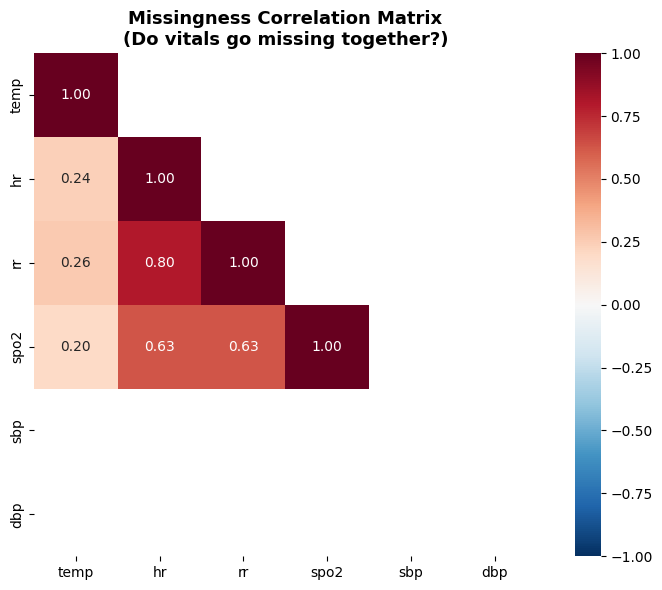

In [5]:
miss_wide = run_query(conn, "missingness_matrix")

# Missingness rates
present_cols = [f"{v}_present" for v in MISS_COLS]
rates = miss_wide[present_cols].mean().round(3)
rates.index = [c.replace("_present", "") for c in rates.index]
print("Presence rates:")
print(rates)

# Correlation heatmap
miss_corr = miss_wide[present_cols].corr()
miss_corr.index = MISS_COLS
miss_corr.columns = MISS_COLS

fig, ax = plt.subplots(figsize=(8, 6))
plot_heatmap(miss_corr, "Missingness Correlation Matrix\n(Do vitals go missing together?)", ax)
plt.tight_layout()
plt.show()

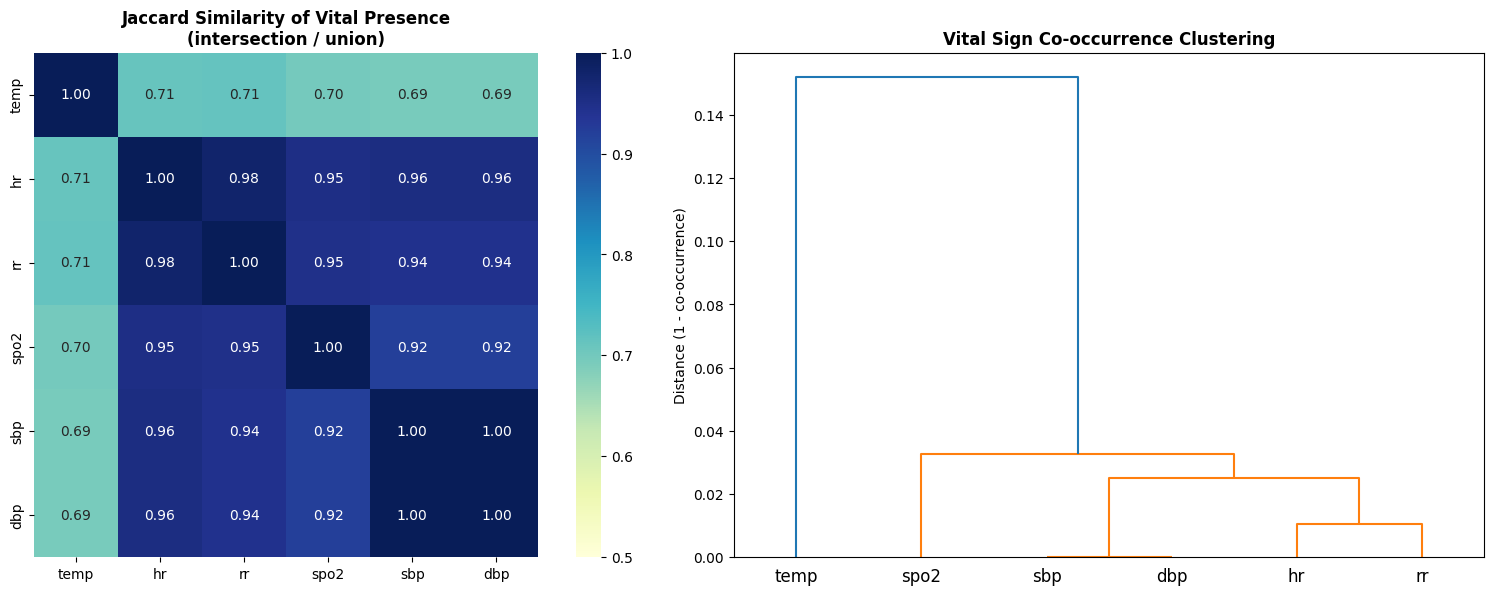

In [6]:
# Co-occurrence matrix + Jaccard heatmap + dendrogram
co_occur = compute_co_occurrence(miss_wide)

# Jaccard similarity
jaccard = pd.DataFrame(index=MISS_COLS, columns=MISS_COLS, dtype=float)
for v1 in MISS_COLS:
    for v2 in MISS_COLS:
        jaccard.loc[v1, v2] = jaccard_score(
            miss_wide[f"{v1}_present"], miss_wide[f"{v2}_present"]
        )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Jaccard heatmap
sns.heatmap(jaccard.astype(float), annot=True, fmt=".2f", cmap="YlGnBu",
            ax=axes[0], vmin=0.5, vmax=1, square=True)
axes[0].set_title("Jaccard Similarity of Vital Presence\n(intersection / union)", fontweight="bold")

# Dendrogram
similarity = co_occur.values.astype(float) / 100
distance = 1 - (similarity + similarity.T) / 2
np.fill_diagonal(distance, 0)
linkage_matrix = linkage(squareform(distance), method="average")
dendrogram(linkage_matrix, labels=MISS_COLS, ax=axes[1], leaf_font_size=12)
axes[1].set_title("Vital Sign Co-occurrence Clustering", fontweight="bold")
axes[1].set_ylabel("Distance (1 - co-occurrence)")

plt.tight_layout()
plt.show()

In [7]:
# Chi-square MCAR test
mcar = test_mcar_chi_square(miss_wide)
print(f"Chi-square statistic: {mcar['chi2']:,.2f}")
print(f"Degrees of freedom:  {mcar['dof']}")
print(f"P-value:             {mcar['p_value']:.2e}")
print(f"Reject MCAR:         {mcar['reject_mcar']}")
print()
display(mcar["contingency"])

# Conditional distribution tests (t-test + KS-test)
cond_vals = run_query(conn, "conditional_values")
results_df = test_conditional_distributions(cond_vals)
display(results_df)

Chi-square statistic: 97,562.66
Degrees of freedom:  1
P-value:             0.00e+00
Reject MCAR:         True



col_0,Others Complete,Others Incomplete
temp_present,,
Temp Missing,471200,113012
Temp Present,1260313,66737


,Vital,Mean (Temp Present),Mean (Temp Absent),t-statistic,t p-value,KS statistic,KS p-value,Cohen's d,n_present,n_absent
0,Heart Rate,81.583077,82.670432,-36.698368,9.939948e-295,0.044525,0.0,-0.057791,1311527,516148
1,Respiratory Rate,17.533534,18.266132,-6.210598,5.279478e-10,0.154560,0.0,-0.012418,1305467,499574
2,SpO2,98.194570,97.515739,29.010610,5.348206e-185,0.106938,0.0,0.048031,1269138,489497
3,Systolic BP,130.650467,127.181188,18.118162,2.325700e-73,0.090551,0.0,0.035552,1306704,508687
4,Diastolic BP,77.043618,72.021069,5.796873,6.757395e-09,0.122479,0.0,0.011401,1306058,508547


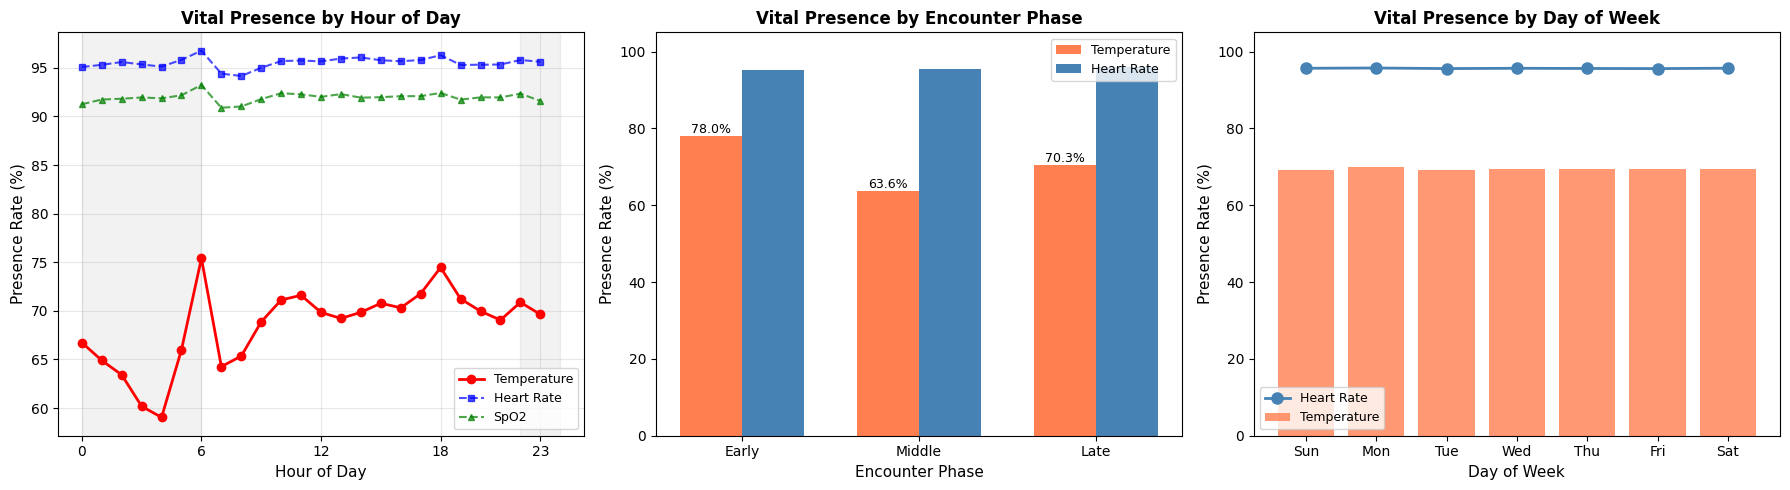

In [8]:
# Temporal missingness patterns
temporal = run_query(conn, "temporal_features")
fig = plot_temporal_panels(temporal)
plt.show()

### 4.2 Recommendation: Drop Temperature

Based on the missingness analysis above, we recommend **excluding temperature**
from the initial LSTM exploratory analysis:

- Temperature is missing ~90% of the time when a timestamp is incomplete
- MCAR is rejected (p < 0.05) — missingness is **not random**
- Dropping temperature dramatically increases the number of usable timestamps

In [ ]:
# 6v vs 5v completeness comparison
comp_6v = run_query(conn, "comparison_6v_vs_5v")
comp_6v.insert(0, "approach", "6 Vitals (with Temp)")
comp_5v = run_query(conn, "comparison_6v_vs_5v", exclude_temp=True)
comp_5v.insert(0, "approach", "5 Vitals (excl. Temp)")
comparison = pd.concat([comp_6v, comp_5v], ignore_index=True)
display(comparison)

n_total = len(miss_wide)
n_complete_6 = int((miss_wide[present_cols].sum(axis=1) == 6).sum())
n_complete_5 = int((miss_wide[[c for c in present_cols if c != "temp_present"]].sum(axis=1) == 5).sum())

print(f"\nComplete timestamps (6v): {n_complete_6:,} / {n_total:,} ({100*n_complete_6/n_total:.1f}%)")
print(f"Complete timestamps (5v): {n_complete_5:,} / {n_total:,} ({100*n_complete_5/n_total:.1f}%)")

## 5. Time Delta Analysis (5 Vitals)

Time deltas between consecutive complete timestamps (all 5 non-temperature vitals present).

,n_deltas,min,p10,p25,p50_median,p75,p90,p95,max
0,1312375,0.3,3.0,36.0,105.0,190.0,279.0,346.0,40201.0


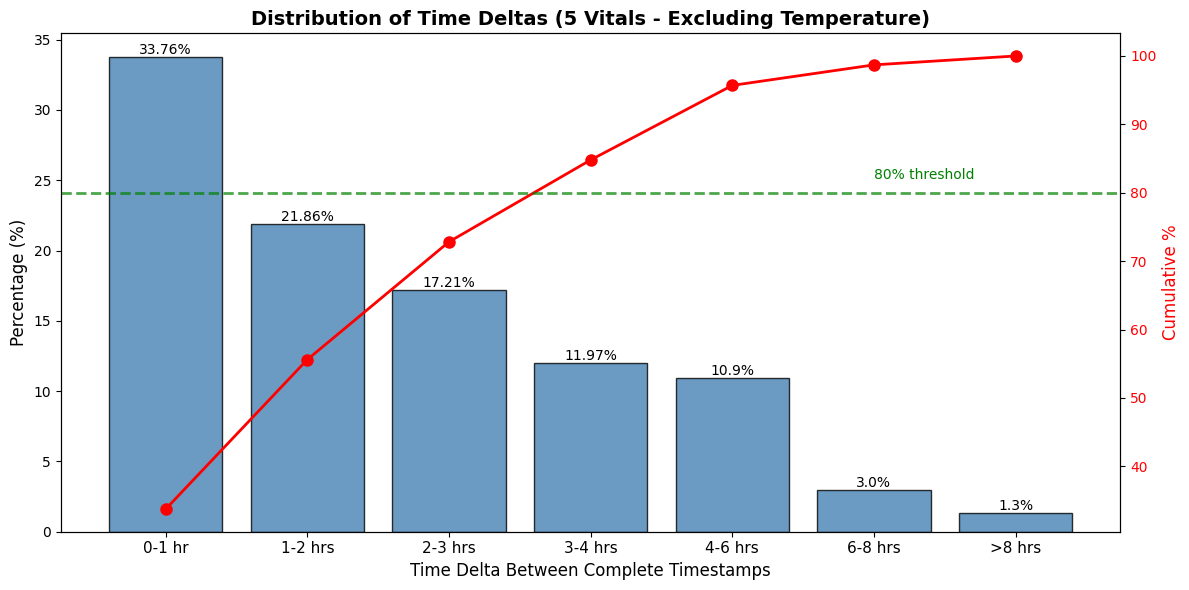

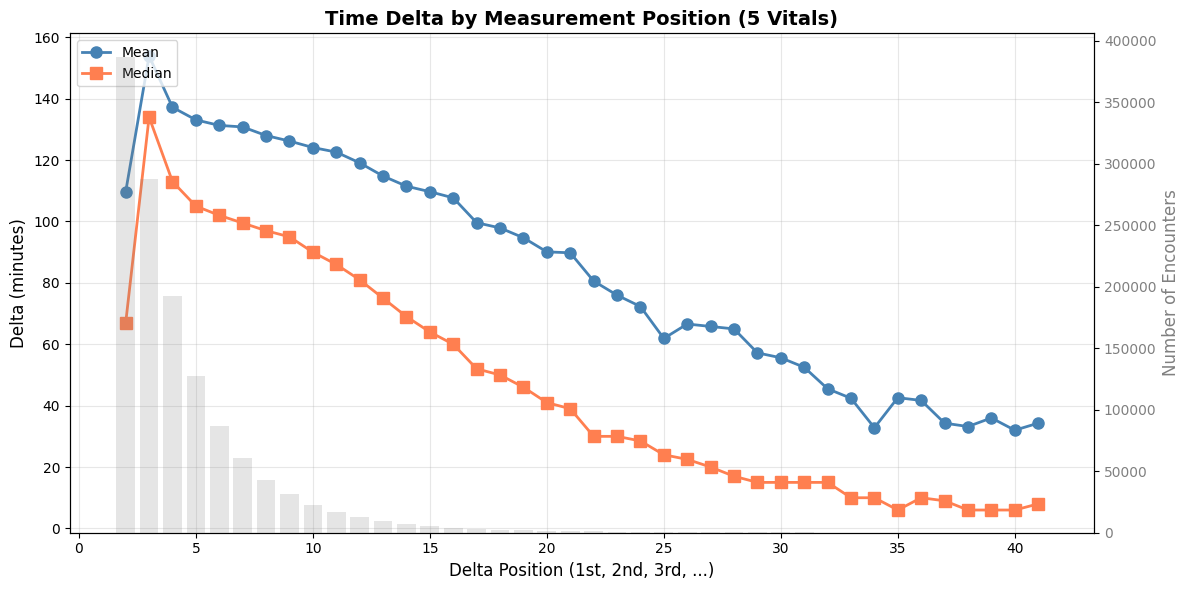

In [10]:
# Percentile summary
delta_stats = run_query(conn, "time_deltas", exclude_temp=True)
display(delta_stats)

# Bucketed histogram
buckets = run_query(conn, "time_delta_buckets", exclude_temp=True)

fig, ax = plt.subplots(figsize=(12, 6))
plot_delta_histogram(buckets, "Distribution of Time Deltas (5 Vitals - Excluding Temperature)", ax)
plt.tight_layout()
plt.show()

# Average delta by measurement position
delta_pos = run_query(conn, "delta_by_position", exclude_temp=True)
plot_data = delta_pos[delta_pos["n_encounters"] >= 50].copy()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(plot_data["delta_idx"], plot_data["avg_delta_min"], "o-", color="steelblue", linewidth=2, markersize=8, label="Mean")
ax1.plot(plot_data["delta_idx"], plot_data["median_delta_min"], "s-", color="coral", linewidth=2, markersize=8, label="Median")
ax1.set_xlabel("Delta Position (1st, 2nd, 3rd, ...)", fontsize=12)
ax1.set_ylabel("Delta (minutes)", fontsize=12)
ax1.set_title("Time Delta by Measurement Position (5 Vitals)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(plot_data["delta_idx"], plot_data["n_encounters"], alpha=0.2, color="gray")
ax2.set_ylabel("Number of Encounters", fontsize=12, color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
plt.tight_layout()
plt.show()

## 6. Sequence Length & Coverage

How many complete timestamps per encounter, and what timestep covers most deltas?

In [ ]:
# Sequence length comparison (6v vs 5v)
seq_6v = run_query(conn, "sequence_lengths")
seq_6v.insert(0, "approach", "6 Vitals (with Temp)")
seq_5v = run_query(conn, "sequence_lengths", exclude_temp=True)
seq_5v.insert(0, "approach", "5 Vitals (excl. Temp)")
seq_lengths = pd.concat([seq_6v, seq_5v], ignore_index=True)
display(seq_lengths)

# Histogram of sequence lengths (5v)
seq_hist = run_query(conn, "sequence_length_hist", exclude_temp=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#ff6b6b" if x in ["0", "1"] else "#6bcb77" for x in seq_hist["seq_length"]]
bars = ax.bar(seq_hist["seq_length"], seq_hist["pct"], color=colors, edgecolor="black")
ax.set_xlabel("Number of Complete Timestamps per Encounter (5 Vitals)", fontsize=12)
ax.set_ylabel("Percentage of Encounters (%)", fontsize=12)
ax.set_title("LSTM Sequence Length Distribution (5 Vitals)", fontsize=14, fontweight="bold")
for bar, pct in zip(bars, seq_hist["pct"]):
    ax.annotate(f"{pct}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#ff6b6b", edgecolor="black", label="Unusable for LSTM (0-1)"),
    Patch(facecolor="#6bcb77", edgecolor="black", label="Usable (2+)"),
], loc="upper right")
plt.tight_layout()
plt.show()

# Timestep coverage
coverage = run_query(conn, "timestep_coverage", exclude_temp=True)
coverage["gaps_to_fill"] = 100 - coverage["pct_covered"]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(coverage))
ax.bar(x, coverage["pct_covered"], color="steelblue", edgecolor="black", alpha=0.8)
ax.bar(x, coverage["gaps_to_fill"], bottom=coverage["pct_covered"], color="lightcoral", edgecolor="black", alpha=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels(coverage["timestep_label"], fontsize=11)
ax.set_xlabel("Fixed Timestep Choice", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("Timestep Coverage: % of Deltas Within Timestep (5 Vitals)", fontsize=14, fontweight="bold")
ax.axhline(y=80, color="green", linestyle="--", linewidth=2, label="80% target")
for i, covered in enumerate(coverage["pct_covered"]):
    ax.annotate(f"{covered}%", xy=(i, covered / 2), ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.legend(handles=[
    Patch(facecolor="steelblue", edgecolor="black", label="Covered (no interpolation)"),
    Patch(facecolor="lightcoral", edgecolor="black", label="Gaps (need interpolation)"),
], loc="lower right")
plt.tight_layout()
plt.show()

## 7. Summary & Recommendations

In [12]:
print("""
KEY FINDINGS
============

1. MISSINGNESS
   - Temperature is the overwhelmingly missing vital (~90% of incomplete timestamps)
   - MCAR rejected: missingness is NOT random (chi-square p < 0.05)
   - Conditional distribution tests show statistically significant (but small effect size)
     differences — consistent with MAR rather than MNAR

2. RECOMMENDATION: DROP TEMPERATURE
   - Switching from 6 to 5 vitals dramatically increases usable data
   - Median time delta drops from ~162 min (6v) to ~105 min (5v)

3. TIME DELTAS (5 Vitals)
   - Median delta: ~105 minutes between complete timestamps
   - ~80% of deltas fall within 4 hours

4. SEQUENCE LENGTHS (5 Vitals)
   - ~91% of encounters have 2+ complete timestamps (usable for LSTM)
   - Median sequence length supports meaningful temporal modeling

5. TIMESTEP RECOMMENDATION
   - A 4-hour timestep covers ~80% of deltas without interpolation
   - Trade-off: smaller timesteps = more granularity but more gaps to fill
""")


KEY FINDINGS

1. MISSINGNESS
   - Temperature is the overwhelmingly missing vital (~90% of incomplete timestamps)
   - MCAR rejected: missingness is NOT random (chi-square p < 0.05)
   - Conditional distribution tests show statistically significant (but small effect size)
     differences — consistent with MAR rather than MNAR

2. RECOMMENDATION: DROP TEMPERATURE
   - Switching from 6 to 5 vitals dramatically increases usable data
   - Median time delta drops from ~162 min (6v) to ~105 min (5v)

3. TIME DELTAS (5 Vitals)
   - Median delta: ~105 minutes between complete timestamps
   - ~80% of deltas fall within 4 hours

4. SEQUENCE LENGTHS (5 Vitals)
   - ~91% of encounters have 2+ complete timestamps (usable for LSTM)
   - Median sequence length supports meaningful temporal modeling

5. TIMESTEP RECOMMENDATION
   - A 4-hour timestep covers ~80% of deltas without interpolation
   - Trade-off: smaller timesteps = more granularity but more gaps to fill



In [13]:
conn.close()
print("Connection closed.")

Connection closed.
